# TP 1: Sequential stock data in one dimension
## Numerical processing of financial data APM 50442 EP

Matthieu Garcin


We're going to work with a large American stock index, the S&P 500 index, whose constituents are the 500 American stocks with the largest capitalization (80% of the capitalization of American stocks: a larger American Index is Russell 3000). The value of the index is the weighted mean of the value of these stocks.

We will focus first on the time series of prices, returns and volatility.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# Import the yfinance package
#(the first two following lines are to be executed if the current version does not contain "adjusted close"; it may require to restart the session if working in Google Colab)
# !pip uninstall yfinance -y --quiet
# !pip install yfinance==0.2.50 --quiet
import yfinance as yf
print(yf.__version__)

# If you get the "ModuleNotFoundError", then
# 1) Either install yfinance by running the command
#  !python -m pip install yfinance --upgrade --no-cache-dir
# from your Jupyter notebook;
# 2) Or run this notebook in Google Colab.

0.2.50


# First analysis

We first upload the historical time series of daily prices of one of the biggest constituents of the S&P 500 index, namely the stock JPMorgan Chase & Co. We retrieve it from the yahoo finance database.

However, yahoo finance has been quite unstable lately. If it does not work, skip Q1 and go directly to Q1*.

## Prices with yfinance (Q1)

In [ ]:
start_date = '2005-01-01'
end_date = '2023-12-31'

data_JPM = yf.download(tickers="JPM", start=start_date, end=end_date)

In [ ]:
import pandas as pd

data_JPM = pd.read_excel("data/BNP_Prices.xlsx", header=1)

Let us have a look at the content of our data frame.

In [ ]:
print("data_JPM shape : ", data_JPM.shape)
data_JPM.head()

Let us plot the series of daily values:

In [ ]:
plt.plot(data_JPM['Adj Close'],label='Adjusted Close')
plt.plot(data_JPM['Close'],label='Close')
plt.title("Time series of JPM stock")
plt.ylabel("stock value")
plt.grid(False)
plt.legend()
plt.show()

**Question 1**: How can one explain the difference between the adjusted close and the close? Does the difference increase progressively or is it explained by a limited number of events?



*   **1.a/** Choose a relevant indicator to find where a new gap appears between Close and Adjusted close. Put it in a new column.



In [ ]:
data_JPM['Adj_Close_to_Close_Indicator'] = ???
data_JPM.head()

In [ ]:
plt.plot ...

In [ ]:
#We define a Boolean to identify variations of this indicator
data_JPM['Indicator_Variation'] = ???
data_JPM.head()



*   **1.b/** Determine the proportion of dates for which there is a variation, as well as the list of corresponding dates.



In [ ]:
#Proportion of dates for which there is a variation
proportion_variation = ???
print("Proportion of days at which the ratio varies:", ???
#Dates at which there is a variation
dates_variation = ???
print("Dates at which there is a variation:")
print(dates_variation)

* **1.c/** Create a histogram depicting the distribution of the length of the time interval between two consecutive jumps of the indicator.



In [ ]:
#time interval (number of days between two successive variations)
time_interval = ???
#Histogram
plt.title("Distribution of the time interval between two successive variations")
...

 * **1.d/**: Is there the same discrepancy between Close and adjusted Close for the S&P 500 index?

In [ ]:
data_SP500 = yf.download(tickers="^GSPC", start=start_date, end=end_date)
...

## Prices with Stooq (Q1*)

In [3]:
import pandas_datareader.data as web

data_JPM = web.DataReader("JPM", "stooq")
data_JPM = data_JPM.sort_index()

print("data_JPM shape : ", data_JPM.shape)
data_JPM.head()

data_JPM shape :  (1255, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2021-01-11,128.169,131.627,127.737,131.481,1.674501e+07
2021-01-12,132.807,134.919,132.237,133.553,1.893345e+07
2021-01-13,132.001,134.113,131.529,133.681,1.555622e+07
2021-01-14,133.819,135.951,133.337,134.457,1.949215e+07
2021-01-15,130.911,134.909,130.507,132.050,2.927247e+07


Contrary to Yahoo finance, we don't have the adjusted close: we only have the close. It will thus be convenient for the rest of the project to rename this field.

In [4]:
data_JPM.rename(columns={'Close': 'Adj Close'}, inplace=True)
data_JPM.head()

,Open,High,Low,Adj Close,Volume
Date,,,,,
2021-01-11,128.169,131.627,127.737,131.481,1.674501e+07
2021-01-12,132.807,134.919,132.237,133.553,1.893345e+07
2021-01-13,132.001,134.113,131.529,133.681,1.555622e+07
2021-01-14,133.819,135.951,133.337,134.457,1.949215e+07
2021-01-15,130.911,134.909,130.507,132.050,2.927247e+07


Let us plot the series of daily values.


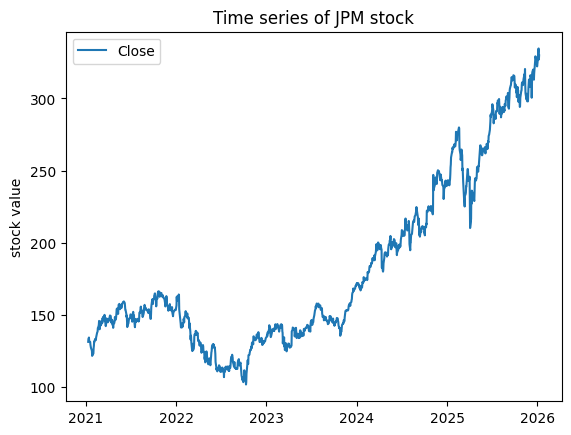

In [5]:
plt.plot(data_JPM['Adj Close'], label='Close')
plt.title("Time series of JPM stock")
plt.ylabel("stock value")
plt.grid(False)
plt.legend()
plt.show()

Let's consider the S&P 500 index. And we're lucky because the adjusted close is equal to the close for stock indices.

In [6]:
data_SP500 = web.DataReader("^SPX", "stooq")
data_SP500 = data_SP500.sort_index()

print("data_SP500 shape : ", data_SP500.shape)
data_SP500.rename(columns={'Close': 'Adj Close'}, inplace=True)
data_SP500.head()

data_SP500 shape :  (1255, 5)


,Open,High,Low,Adj Close,Volume
Date,,,,,
2021-01-11,3803.14,3817.86,3789.02,3799.61,2.335918e+09
2021-01-12,3801.62,3810.78,3776.51,3801.19,2.632132e+09
2021-01-13,3802.23,3820.96,3791.50,3809.84,2.344888e+09
2021-01-14,3814.98,3823.60,3792.86,3795.54,2.708930e+09
2021-01-15,3788.73,3788.73,3749.62,3768.25,2.741656e+09


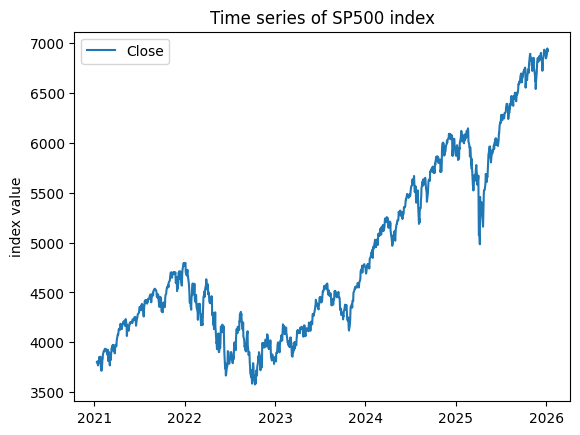

In [7]:
plt.plot(data_SP500['Adj Close'], label='Close')
plt.title("Time series of SP500 index")
plt.ylabel("index value")
plt.grid(False)
plt.legend()
plt.show()

# Daily returns

We wish to analyze the series of daily returns that we can extract from the series above of daily valus of the S&P 500.

The cell below casts the series of observation dates and the corresponding values of the S&P 500 index ('Adj Close' column) onto numpy arrays. You can either manipulate these numpy arrays or directly work with the Series objects from the DataFrame (as above) -- this is up to you.

In [8]:
dates = np.array(data_SP500.index)
values = np.array(data_SP500['Adj Close'])

## Arithmetic returns (Q2)

Let $S_t$ be the daily series of values observed for the SP500 index, for $t \in \text{dates}$.

The arithmetic returns $R_t$ are defined by
$$
R_t = \frac{S_{t+1} - S_t}{S_t} = \frac{S_{t+1}}{S_t} - 1.
$$

**Question 2:** What are the artihmetic price returns? Do they provide us with a stationary time series? Compare to the time series of prices.

*   **2.a/** Construct the time-series of arithmetic returns and plot it against the observation dates.

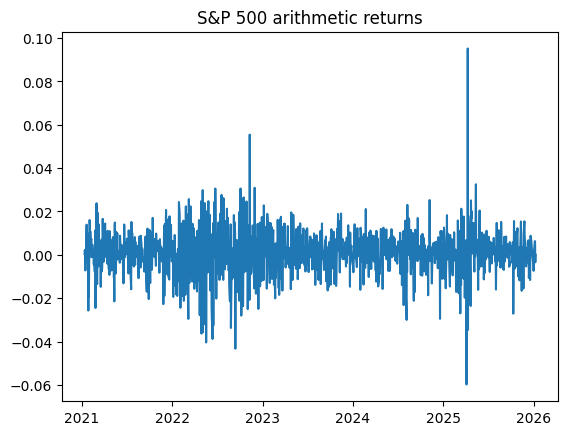

In [66]:
from datetime import date
arithmetic_returns = values[1:] / values[:-1] - 1
return_dates = dates[1:]

plt.title("S&P 500 arithmetic returns")
plt.plot(return_dates, arithmetic_returns)
plt.show()

* **2.b/** Use the augmented Dickey-Fuller test to determine whether the price and the return series are stationary.

In [29]:
from statsmodels.tsa.stattools import adfuller

# Apply ADF test to prices
print("Applying ADF test to prices:")

result = adfuller(values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])  # type: ignore
if result[1] <= 0.05:
    print("The non-stationarity hypothesis (H_0) is rejected for prices (p-value <= 0.05).")
else:
    print("The non-stationarity hypothesis (H_0) is not rejected for prices (p-value > 0.05).")

# Apply ADF test to price returns
print("\nApplying ADF test to price RETURNS:")

result = adfuller(arithmetic_returns)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])  # type: ignore
if result[1] <= 0.05:
    print("The non-stationarity hypothesis (H_0) is rejected for price returns (p-value <= 0.05).")
else:
    print("The non-stationarity hypothesis (H_0) is not rejected for price returns (p-value > 0.05).")

Applying ADF test to prices:
ADF Statistic: 0.20072091639409162
p-value: 0.9723019989633725
Critical Values: {'1%': np.float64(-3.435592223709696), '5%': np.float64(-2.8638549702604803), '10%': np.float64(-2.56800251776)}
The non-stationarity hypothesis (H_0) is not rejected for prices (p-value > 0.05).

Applying ADF test to price RETURNS:
ADF Statistic: -21.93722921091443
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4355880246374304), '5%': np.float64(-2.8638531175675896), '10%': np.float64(-2.568001531098063)}
The non-stationarity hypothesis (H_0) is rejected for price returns (p-value <= 0.05).


* **2.c/** Display the (stationary) distribution of price returns using a histogram.

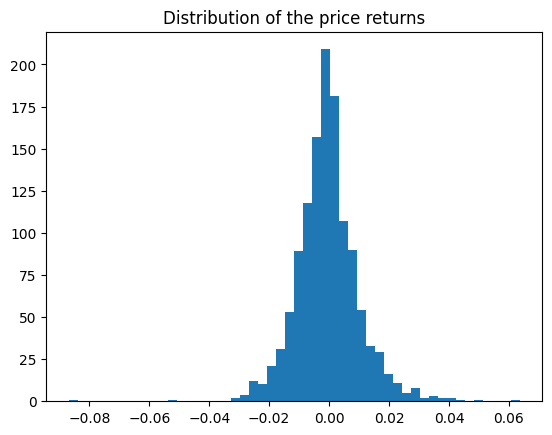

In [38]:
# Histogram
plt.title("Distribution of the price returns")
plt.hist(arithmetic_returns, bins=50)
plt.show()

* **2.d/**  Does it look like a Gaussian distribution?



Mean of returns:  -0.00042134366593756076
Variance of returns:  0.00011368218282023778
Skewness of returns:  0.13226226263858135
Kurtosis of returns:  5.981680070428455
The Gaussian nature of the kurtosis of the returns (H_0) is rejected (p-value = 5.659863114843439e-38).
The Gaussian nature of the distribution of the returns (H_0) is rejected (p-value = 3.2671243484787746e-06).


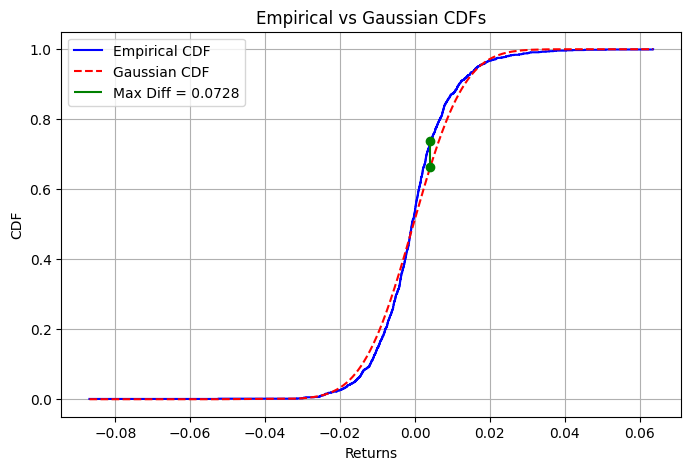

In [62]:
# Test using moments
import scipy.stats as stats

result_stats = stats.describe(arithmetic_returns)
print("Mean of returns: ", result_stats.mean)
print("Variance of returns: ", result_stats.variance)
print("Skewness of returns: ", result_stats.skewness)
print("Kurtosis of returns: ", result_stats.kurtosis)

# Kurtosis test with stats.kurtosistest
result = stats.kurtosistest(arithmetic_returns)
if result.pvalue <= 0.05:
    print(f"The Gaussian nature of the kurtosis of the returns (H_0) is rejected (p-value = {result.pvalue}).")
else:
    print(f"The Gaussian nature of the kurtosis of the returns (H_0) is not rejected (p-value = {result.pvalue}).")

# Kolmogorov-Smirnov test with stats.kstest
result = stats.kstest(arithmetic_returns, 'norm', args=(np.mean(arithmetic_returns), np.std(arithmetic_returns)))
if result.pvalue <= 0.05:
    print(f"The Gaussian nature of the distribution of the returns (H_0) is rejected (p-value = {result.pvalue}).")
else:
    print(f"The Gaussian nature of the distribution of the returns (H_0) is not rejected (p-value = {result.pvalue}).")
    
# Illustration of Kolmogorov-Smirnov: empirical and Gaussian cdf and highlighting max divergence between them.
# Empirical and Gaussian cdf in the same grid (corresponding to data)
sorted_returns = np.sort(arithmetic_returns)
n = len(sorted_returns)
empirical_cdf = np.arange(1, n+1) / n
gaussian_cdf = stats.norm.cdf(sorted_returns, loc=result_stats.mean, scale=result_stats.variance**0.5)

# Divergence between one cdf and the other
divergence_array = np.abs(empirical_cdf - gaussian_cdf)
max_divergence_index = np.argmax(divergence_array)
max_divergence = divergence_array[max_divergence_index]

# Visualisation
plt.figure(figsize=(8,5))
plt.step(sorted_returns, empirical_cdf, where='post', label='Empirical CDF', color='blue')
plt.plot(sorted_returns, gaussian_cdf, label='Gaussian CDF', color='red', linestyle='--')
plt.xlabel('Returns')
plt.ylabel('CDF')
plt.scatter(sorted_returns[max_divergence_index], empirical_cdf[max_divergence_index], color='green', zorder=5)
plt.scatter(sorted_returns[max_divergence_index], gaussian_cdf[max_divergence_index], color='green', zorder=5)
plt.vlines(sorted_returns[max_divergence_index], empirical_cdf[max_divergence_index], gaussian_cdf[max_divergence_index],
           color='green', label=f'Max Diff = {max_divergence:.4f}')
plt.legend()
plt.title('Empirical vs Gaussian CDFs')
plt.grid(True)
plt.show()

Possible extension: You could do the same exercise by simply changing the time interval. Zooming in a shorter period may lead to other empirical observations. For example, some simple models (Gaussian, e.g.) may be relevant at short time scales (that is it is impossible to statistically reject them) but not for longer ones. Finding the threshold of scale above which a model is flawed is a useful knowledge.

## Logarithmic returns (Q3)

The logarithmic returns $\widehat R_t$ are defined by
$$
\widehat R_t = \log \frac{S_{t+1}}{S_t}.
$$
Note that, due to the first order Taylor expansion $\log(1 + x) = x + O(x^2)$ for $x \to 0$, we have

$$
\widehat R_t
= \log \Bigl( 1 +  \frac{S_{t+1} - S_t}{S_t} \Bigr)
= \log \Bigl( 1 + R_t \Bigr)
= R_t + O(R_t^2),
$$

which provides a good approximation of the logarithmic returns as soon as the (relative) returns are not too large.

Therefore, we expect logarithmic returns and relative returns to be close to each other.

**Question 3:** Calculate these returns and compare them to arithmetic one.

* **3.a/** Construct the series of logarithmic returns and plot it against the observation dates.

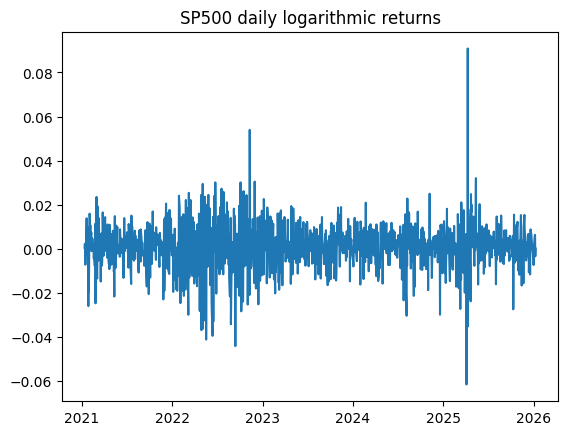

In [46]:
log_returns = np.log(values[1:] / values[:-1])

plt.title("SP500 daily logarithmic returns")
plt.plot(dates[1:], log_returns)
plt.show()

* **3.b/** Compare some basic statistics of relative returns and logarithmic returns (mean, standard deviation, min and max values) together with their histograms.

In [65]:
mean_return = np.mean(arithmetic_returns)
std_return = np.std(arithmetic_returns)
arithmetic_min = np.min(arithmetic_returns)
arithmetic_max = np.max(arithmetic_returns)
log_mean = np.mean(log_returns)
log_std = np.std(log_returns)
log_min = np.min(log_returns)
log_max = np.max(log_returns)

print("Empirical mean : arithmetic returns = %1.5f, logarithmic returns = %1.5f" %(mean_return, log_mean) )
print("Empirical st dev : arithmetic returns = %1.5f, logarithmic returns = %1.5f" %(std_return, log_std) )
print("Min and max values : arithmetic returns in [%1.3f, %1.3f], logarithmic returns in [%1.3f, %1.3f]" %(arithmetic_min, arithmetic_max, log_min, log_max) )

Empirical mean : arithmetic returns = -0.00042, logarithmic returns = 0.00048
Empirical st dev : arithmetic returns = 0.01066, logarithmic returns = 0.01066
Min and max values : arithmetic returns in [-0.087, 0.064], logarithmic returns in [-0.062, 0.091]


The histograms:

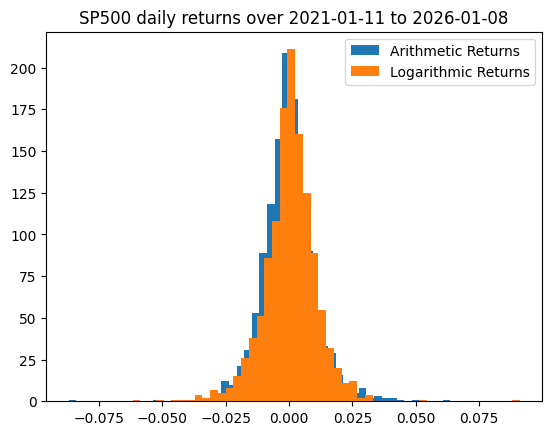

In [60]:
import pandas as pd
start_date = (pd.to_datetime(str(dates[0]))).strftime('%Y-%m-%d')
end_date = (pd.to_datetime(str(dates[-1]))).strftime('%Y-%m-%d')

plt.title("SP500 daily returns over "+start_date+" to "+end_date)
plt.hist(arithmetic_returns, bins=50, label="Arithmetic Returns")
plt.hist(log_returns, bins=50, label="Logarithmic Returns")
plt.legend()
plt.show()

* **3.c/** Test statically the adequation of the moments, using a paired difference test (based on a t-test).

In [68]:
# ToDo

# Visualize the difference
...
plt.title("Difference log-arithmetic return compared to arithmetic return")
...

# A statistical test
# T-test for paired datasets with stats.ttest_rel
...
if ???:
    print("There is a significant difference between the two distributions.")
else:
    print("There is no significant difference between the two distributions.")

SyntaxError: invalid syntax (947041576.py, line 11)

# Volatility

Using a dataset (Excel files) of one-minute observations (OHLC prices), we are going to estimate volatility by various means. The dataset consists in the 40 constituents of the French stock index CAC 40 (as of 2022/2023). The biggest capitalizations are: LVMH (MC), L'Oréal (OR), TotalEnergies (TTE), Sanofi (SAN), Hermès (RMS), Airbus (AIR)...

The time range is September 2022-March 2023. Pay attention to the fact that there are variations of a few days between starting dates of two time series. Some stocks also don't have a price every minute (less liquid, like SW).



## Realized volatility (Q4)

The realized volatility is the standard deviation of non-overlapping intraday arithmetic price returns, for a given time scale (1 minute, 5 minute, etc.). The bigger the time step, the lower the number of observations, and the higher the variance of the estimator.

**Question 4**: Calculate the realized volatility of an asset of your choice among those provided for the tutorial.

* **4.a/** Import the data (if using Google Colab, save them in the files in your project) and build a time series of realized volatility based on a one-minute returns.

In [71]:
#Import the data
import pandas as pd
#!pip install openpyxl (if necessary)
data_AIR = pd.read_excel('data/AIR_Prices.xlsx', engine='openpyxl', header=1)  # header=1 indicates the right lign where to find the headers
print(data_AIR.head())

                Dates    Open   Close    High     Low
0 2022-09-13 09:00:00  100.24  100.28  100.38  100.14
1 2022-09-13 09:01:00  100.26  100.26  100.36  100.22
2 2022-09-13 09:02:00  100.24  100.24  100.26  100.22
3 2022-09-13 09:03:00  100.22  100.26  100.28  100.12
4 2022-09-13 09:04:00  100.22  100.26  100.26  100.20


In [91]:
# Create a column for the date only, for the time only, and one for the price return
data_AIR['Date only'] = data_AIR['Dates'].dt.date  # type: ignore
data_AIR['Hour_Minute'] = data_AIR['Dates'].dt.strftime('%H:%M')  # type: ignore
data_AIR['Return'] = data_AIR['Close'].pct_change()
print(data_AIR.head(5))

                Dates    Open   Close    High     Low   Date only Hour_Minute  \
0 2022-09-13 09:00:00  100.24  100.28  100.38  100.14  2022-09-13       09:00   
1 2022-09-13 09:01:00  100.26  100.26  100.36  100.22  2022-09-13       09:01   
2 2022-09-13 09:02:00  100.24  100.24  100.26  100.22  2022-09-13       09:02   
3 2022-09-13 09:03:00  100.22  100.26  100.28  100.12  2022-09-13       09:03   
4 2022-09-13 09:04:00  100.22  100.26  100.26  100.20  2022-09-13       09:04   

     Return  
0       NaN  
1 -0.000199  
2 -0.000199  
3  0.000200  
4  0.000000  


In [92]:
# Group the data by day (excluding the first line, which is a return between two distinct days)
grouped = data_AIR.groupby("Date only")["Return"]

# Exclude first intraday return for each day and compute per-day stats
daily_volatility = grouped.apply(lambda x: x.iloc[1:].std())
daily_count = grouped.apply(lambda x: x.iloc[1:].count())

# Create a dataframe for the dates and the volatility values
daily_stats_AIR_df = pd.DataFrame(
    {"Volatility": daily_volatility, "Count": daily_count}
)
print(daily_stats_AIR_df.head())

            Volatility  Count
Date only                    
2022-09-13    0.000880    508
2022-09-14    0.000665    511
2022-09-15    0.000611    509
2022-09-16    0.000639    512
2022-09-19    0.000627    510


* **4.b/** Annualize this volatility.

In [94]:
daily_stats_AIR_df['1-mn vol'] = daily_stats_AIR_df['Volatility'] * np.sqrt(252 * 512)
print(daily_stats_AIR_df.head())

            Volatility  Count  1-mn vol
Date only                              
2022-09-13    0.000880    508  0.316014
2022-09-14    0.000665    511  0.238979
2022-09-15    0.000611    509  0.219484
2022-09-16    0.000639    512  0.229541
2022-09-19    0.000627    510  0.225358


* **4.c/** Calculate also annualized realized volatilities each day for other time steps (2 minutes, 3 minutes, 30 minutes). We accept you use overlapping increments.

In [98]:
# Create a new dataframe for the volatilities
volatility_df = pd.DataFrame()

for interval in range(2, 31):  # From 2 to 30 minutes
    # Calculate returns
    col_name = f'{interval}-mn Return'
    data_AIR[col_name] = data_AIR['Close'].pct_change(periods=interval)
    
    # Exclude first observation
    data_AIR[col_name] = data_AIR.groupby("Date only")[col_name].shift(1)
    
    # Calculate the volatility
    volatility_col = f'{interval}-mn vol'
    volatility_df[volatility_col] = data_AIR.groupby("Date only")[col_name].std()
    
    # Annualize
    volatility_df[volatility_col] = volatility_df[volatility_col] * np.sqrt(252 * (512 / interval))
    
    # Number of observations
    count_col = f'{interval}-mn Count'
    volatility_df[count_col] = data_AIR.groupby("Date only")[col_name].count()

# Put the results in daily_stats_AIR_df
daily_stats_AIR_df = pd.concat([daily_stats_AIR_df, volatility_df], axis=1)

# Print the result
print(daily_stats_AIR_df.head())

            Volatility  Count  1-mn vol  2-mn Volatility  2-mn Count  \
Date only                                                              
2022-09-13    0.000880    508  0.316014         0.294931         506   
2022-09-14    0.000665    511  0.238979         0.264002         511   
2022-09-15    0.000611    509  0.219484         0.224205         509   
2022-09-16    0.000639    512  0.229541         0.426473         512   
2022-09-19    0.000627    510  0.225358         0.233169         510   

            3-mn Volatility  3-mn Count  4-mn Volatility  4-mn Count  \
Date only                                                              
2022-09-13         0.299660         505         0.301850         504   
2022-09-14         0.254775         511         0.255317         511   
2022-09-15         0.216442         509         0.210933         509   
2022-09-16         0.426759         512         0.432875         512   
2022-09-19         0.238488         510         0.242758       

* **4.d/** Plot the trajectories of the various volatilities.

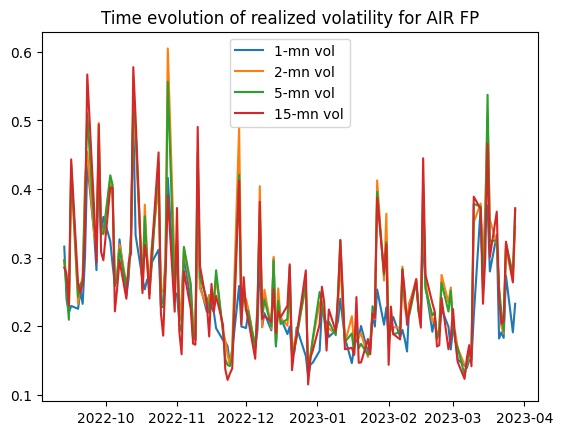

In [101]:
# Select the columns to be displayed
volatility_columns = ['1-mn vol', '2-mn vol', '5-mn vol', '15-mn vol']

# Plot them
plt.title('Time evolution of realized volatility for AIR FP')
plt.plot(daily_stats_AIR_df[volatility_columns])
plt.legend(volatility_columns)
plt.show()

* **4.e/** For a given day, plot the various volatilities as a function of the time scale.

In [ ]:
# Choose a specific day and filter the corresponding data
daily_stats_AIR_df.index = pd.to_datetime(daily_stats_AIR_df.index) # Otherwise not recognized as a date
specific_day = '2022-12-15' # You can try for other dates and will not always get the same shape.
day_data = ...

# Define the time intervals (in minutes) for which we want to plot volatility
time_intervals = ???

# Extract volatility values for each time interval
...

# Plot volatilities as a function of time scale
...

How can you explain that this is not a constant function?

* **4.f/** We now want to have an idea of the volatility depending of the moment in the day. Calculate the standard deviation of all the returns at the same time, whatever the day.

In [ ]:
# Group by 'Hour_Minute' and calculate the standard deviation of returns for each time of day
volatility_by_time = ???

# Display the result
plt.title('Vol of 1-mn returns depending on time')
...

## Parkinson volatility (Q5)

**Question 5:** Compute the two estimators
$$\widehat{D_{1,n}}=\frac{1}{n\sqrt{\tau}}\sum_{i=1}^n d_{(i-1)\tau,i\tau}\sqrt{\frac{\pi}{8}}$$
and
$$\widehat{D_{2,n}}=\left(\frac{1}{n\sqrt{\tau}}\sum_{i=1}^n d^2_{(i-1)\tau,i\tau}\frac{1}{4\ln(2)}\right)^{1/2},$$
where $d_{(i-1)\tau,i\tau}$ is the log high-low range.

* **5.a/** Calculate the Parkinson volatility of the same asset as the one used in the "Realized volatility" section, using high-low ranges at a 1-minute interval, and compare to the realized volatility.



In [ ]:
# High-low range
data_AIR['Log High Low'] = ???
print(data_AIR.head())

In [ ]:
# Group the data by day
# Calculate the first two moments of the range
...

# Deduce Parkinson volatilities (with annualization)
...

# Put the results in daily_stats_AIR_df
...

In [ ]:
# Compare in a graph realized vol and Parkinson vol
volatility_columns = ['1-mn vol', 'Parkinson1', 'Parkinson2']
plt.title('Time evolution of realized/Parkinson volatility for AIR FP')
...

* **5.b/** Do the same for a one-day interval (no intraday prices anymore). Does the statistical theory still apply? Analyze the difference between the two approaches (realized and Parkinson) in this case.




In [ ]:
# Create a dataframe aggregating the OHLC prices in data_AIR at a daily scale
daily_data = ???

# Add close-to-close absolute arithmetic return (low scale realized vol)
...

# Add low-scale Parkinson volatilities
...

# Annualize
...

# Display
plt.title('Time evolution of low-scale realized/Parkinson volatility for AIR FP')
...

In [ ]:
# Some descriptive statistics of the three series
stats = daily_data[volatility_columns].describe()
print(stats)

# Histogram (alpha drives the transparency)
...

# Scatter plot
import seaborn as sns
...

# Serial dependence

We will consider successively a linear measure of dependence (autocorrelation function) and a nonlinear one (serial information).

## Autocorrelation function (Q6)

The autocorrelation function $\tau \mapsto \gamma(\tau)$ of the series of returns ($R_t$) is defined as follows:
$$\gamma(\tau) = \mathrm{Corr}(R_{t+\tau}, R_t)
= \frac{\mathbb E[R_{t+\tau} R_{t}] - \mathbb E[R_{t+\tau}] \mathbb E[R_{t}]}{ \bigl(\mathrm{Var}(R_{t+\tau}) \mathrm{Var}(R_t) \bigr)^{1/2}}
$$
for a given time lag $\tau$.

We can estimate $\gamma(\tau)$ from the observed time series, by replacing expectations with empirical means. Of course, we can consider arithmetic returns or logarithmic ones.

**Question 6:** Calculate the autocorrealtion function of various quantities.

* **6.a/** Write a function evaluating the empirical autocorrelation function.


In [ ]:
def autocorrelation(returns, time_lag):
  """
  returns : ndarray, containing daily returns
  time_lag : integer, representing the time lag in terms of number of days
  """
  ...

* **6.b/** Write a function returning the asymptotic confidence interval for a zero correlation.

In [ ]:
from scipy.stats import norm

def AsymptoticConfidenceNoCorrel(n, alpha=0.95):
    """
    Parameters:
    n (int): size of the sample
    alpha (float): significance level (by default 0.95)

    Returns:
    Lower and upper bounds.
    """
    ...

* **6.c/** Apply these two functions and plot the empirical autocorrelation function of the series of daily price returns of the S&P 500 index (used in the first sections of this notebook) for time lags $\tau \in {0,1,\dots, 30}$ (or longer).

In [ ]:
window = 30
...
plt.title("Autocorrelation function of S&P 500 index daily returns")
...

* **6.d/** Calculate the autocorrelation of the absolute value of price returns of the S&P 500 index.

In [ ]:
...

* **6.e/** Plot the autocorrelation function of the daily volatility calculated with your high-frequency dataset (that is for a stock of the CAC 40 index).

In [ ]:
volatility_columns = ['1-mn vol', '15-mn vol', 'Parkinson1', 'Parkinson2']
...

* **6.f/** Plot the autocorrelation function of the log-variations of the daily volatility calculated with your high-frequency dataset.

In [ ]:
volatility_columns = ['1-mn vol', 'Parkinson1']
...

* **6.g/** What can you conclude about the dynamic of the daily volatility? Keep in mind that volatility is not observed but only estimated.




## Spearman's rank correlation (Q7)

**Question 7:** Write a function returning Spearman's coefficient and apply it to the serial dependence of price returns and volatility increments, along with confidence bounds of an absence of comonotonicity.

In [ ]:
# The function calculating Spearman's correlation coefficient

def autocorrelation_Spearman(returns, time_lag):
  """
  returns : array, containing daily returns
  time_lag : integer, representing the time lag in terms of number of days
  """
  # First transforming returns in ranks (np.argsort will be useful)
  ...

  return correlation

In [ ]:
# Application to price returns

window = 30

...

In [ ]:
# Application to volatility increments

volatility_columns = ['1-mn vol', 'Parkinson1']
...

## Serial information (Q8)

**Question 8:** Calculate the serial information of the above financial time series.

* **8.a/** Start by writing four functions returning:
  * the binary Gray's code,
  * the probability $p_i^L$ of sub-series of length $L$,
  * the corresponding entropy $H^L$,
  * the serial information $I^{L+1}=1+H^L-H^{L+1}$, for $L\in [\![1,L^{\max}]\!]$.

In [ ]:
# Write a function for determining the Gray's code of a binary array
def binary_Gray_code(binary_array):
    ...

# Write a function for estimating the probability of a binary sub-series
def proba_binary_subseries(time_series, L):
    # Initialization
    nb_states = ???
    proba_subseries = np.zeros(???)
    nb_subseries = ???

    # Building sub-series and determining frequencies
    ...


# Write a function returning the entropy H^L
def serial_binary_entropy(proba_subseries):
    ...

# Write a function returning the serial information I^{L+1} for a range of values for L
def serial_binary_information(time_series, L_max):
    entropy = ???
    info = ???
    values_of_L = ???

    return values_of_L, info

* **8.b/** Write a function returning the asymptotic confidence bound for a zero serial information, using the Gamma distribution.

In [ ]:
from scipy.stats import gamma

def AsymptoticConfidenceNoSerialInfo(L, n, alpha=0.95):
    """
    Parameters:
    n (int): size of the sample
    alpha (float): significance level (by default 0.95)

    Return:
    just an upper bound.
    """
    ...

* **8.c/** Calculate the serial information of the series of daily price returns of the S&P 500 index (as a function of $L$).



In [ ]:
L_max = 10

binary_returns = ???
...
plt.title("Serial information function of S&P 500 index daily returns")
...

* **8.d/** Plot the serial information of the log-variations of the daily volatility calculated with your high-frequency dataset.


In [ ]:
L_max = 6

# Calculating the information of the series of increment of each volatility
volatility_columns = ['1-mn vol', 'Parkinson1']
...

# confidence bound
...

# Display the result
...